In [314]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

import warnings
from typing import List, Optional, Tuple
import os
import copy

import mlflow
import mlflow.pytorch
import json

import numpy as np
import optuna
import pandas as pd
from optuna.samplers import TPESampler
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from mlflow.tracking import MlflowClient

In [315]:
# Настроиваем pandas
# Показывать все столбцы
pd.set_option("display.max_columns", None)
# Отображать полный текст в ячейках столбцов без усечения
pd.set_option("display.max_colwidth", None)

In [316]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
path = f"{PROJECT_ROOT}/mlruns"

# создаём mlruns и .trash, если нет
os.makedirs(os.path.join(path, ".trash"), exist_ok=True)

mlflow.set_tracking_uri(f"file://{path}")
mlflow.set_experiment("spaceship_titanic")

<Experiment: artifact_location=('file:///Users/admin/DataSince/Kaggle competitions/Spaceship '
 'Titanic/mlruns/689233284165520319'), creation_time=1767104868196, experiment_id='689233284165520319', last_update_time=1767104868196, lifecycle_stage='active', name='spaceship_titanic', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [317]:
df_train = pd.read_csv(('../data/processed/train_3'))
df_test = pd.read_csv('../data/processed/test_3')
df_train.shape, df_test.shape

((8693, 55), (4277, 54))

In [318]:
X = df_train.drop(["PassengerId", "Name", "Transported"], axis=1)
y = df_train.Transported
X.shape, y.shape

((8693, 52), (8693,))

In [319]:
X_test = df_test.drop(["PassengerId", "Name"], axis=1)
X_test.shape

(4277, 52)

In [320]:
cat_cols = X.select_dtypes(include="object").columns.tolist()
len(cat_cols)

10

In [321]:
num_cols = X.select_dtypes(include="number").columns.tolist()
print(len(num_cols))

42


In [322]:
# Кодирование категорий в индексы
encoders = {}
for col in cat_cols:
    # общий список значений train+test
    all_values = pd.concat([df_train[col], df_test[col]], axis=0)
    

    # # превращаем в категорию и берём категории
    # cats — это объект типа pandas.Index, который хранит уникальные категории этого признака в отсортированном виде
    cats = pd.Categorical(all_values).categories
    mapping = {cat: i for i, cat in enumerate(cats)}
    encoders[col] = mapping
    X[col + "_idx"] = X[col].map(mapping).astype("int64")
    X_test[col + "_idx"]  = X_test[col].map(mapping).astype("int64")
X.shape, X_test.shape

((8693, 62), (4277, 62))

In [323]:
cat_idx_cols = [c + "_idx" for c in cat_cols]
len(cat_idx_cols)

10

In [324]:
# Dataset 

# создадим новыйкласс унаследованный от Dataset
# в конструктор класса пердаются нампай массивы, нужно преобразовать их в торч тензоры. 
# Кастуем эл-ты к типу float32, так как пайторч обычно работает с этим типом данных, вычисления с ним происходят быстрее,
# а32 бита хватает чтобы обеспечивать достаточную точность. Это семь цифр после точки (3.1415927)
# __getitem__ возвращает сэмпл по индексам 
# __len__ возвращает кол-во сэмплов в датасете 

class SpaceshipDataset(Dataset):
    def __init__(self, df, num_cols, cat_idx_cols, y=None):
        self.num = df[num_cols].values.astype("float32")
        self.cat = df[cat_idx_cols].values.astype("int64")
        self.y = None if y is None else np.asarray(y, dtype="float32")
        self.cat_idx_cols = cat_idx_cols

    def __len__(self):
        return len(self.num)

    def __getitem__(self, idx):
        x_num = torch.from_numpy(self.num[idx])            # (n_num,)
        cat_vals = self.cat[idx]                           # (n_cat,)
        x_cat = {
            col: torch.tensor(cat_vals[i], dtype=torch.long)
            for i, col in enumerate(self.cat_idx_cols)
        }
        if self.y is None:
            return x_num, x_cat
        y = torch.tensor(self.y[idx], dtype=torch.float32)
        return x_num, x_cat, y

In [325]:
# Выбор размеров эмбеддингов
def emb_dim(n_cat: int) -> int:
    return min(50, int(round((n_cat ** 0.5) * 2)))

emb_info = [] # список (col, n_cat, dim)
for col, idx_col in zip(cat_cols, cat_idx_cols):
    mapping = encoders[col]           # dict {категория: индекс}
    n_cat = len(mapping)              # все категории train+test
    dim = emb_dim(n_cat)
    emb_info.append((idx_col, n_cat, dim))

emb_info

[('HomePlanet_idx', 3, 3),
 ('Cabin_idx', 9826, 50),
 ('Destination_idx', 4, 4),
 ('deck_idx', 9, 6),
 ('side_idx', 2, 3),
 ('family_name_idx', 2407, 50),
 ('family_id_idx', 9827, 50),
 ('privat_spent_cat_idx', 6, 5),
 ('family_spent_cat_idx', 6, 5),
 ('age_cat_idx', 7, 5)]

In [326]:
# Модель с эмбеддингами
class TabularEmbeddingNN(nn.Module):
    def __init__(self, emb_info, n_num_features):
        super().__init__()

        self.emb_layers = nn.ModuleDict()
        emb_out_total = 0

        for col, n_cat, dim in emb_info:
            self.emb_layers[col] = nn.Embedding(
                num_embeddings=n_cat,
                embedding_dim=dim
            )
            emb_out_total += dim

        self.n_num_features = n_num_features
        in_dim = emb_out_total + n_num_features

        self.mlp = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
        )

    def forward(self, x_num, x_cat_dict):
        embs = []
        for col, emb in self.emb_layers.items():
            embs.append(emb(x_cat_dict[col]))           # (batch, dim)
        x_cat = torch.cat(embs, dim=1)                  # (batch, sum_dim)
        x = torch.cat([x_num, x_cat], dim=1)
        logits = self.mlp(x).squeeze(1)                 # (batch,)
        return logits

Fold 0


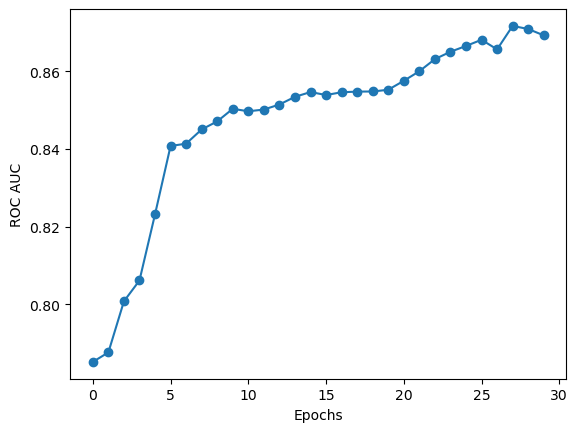

Fold 1


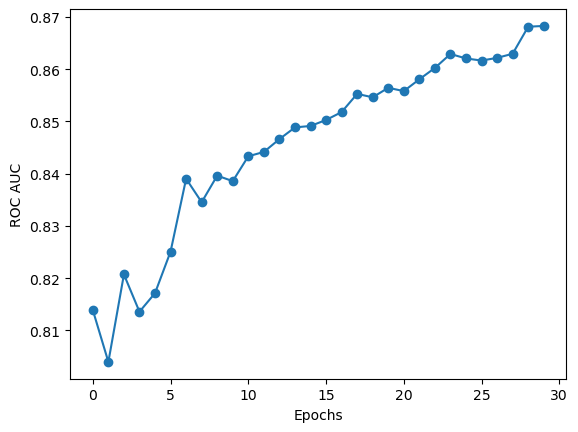

Fold 2


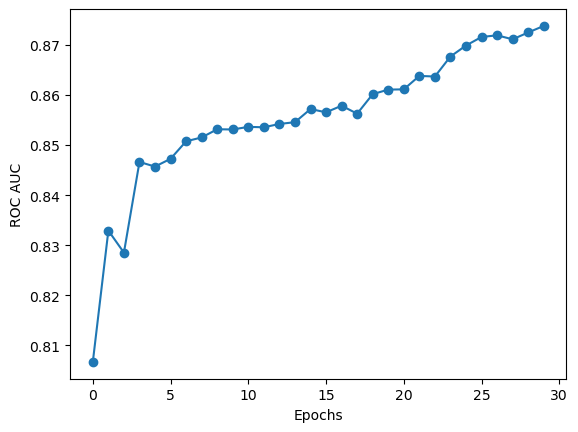

Fold 3


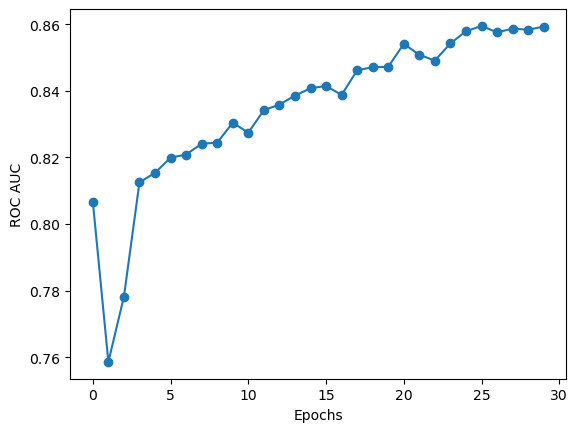

Fold 4


In [ ]:
# KFold + один MLflow run
run_name = "pytorch_cv5_baseline_52features_batch256_epochs30"

batch_size = 256
num_epochs = 30
lr = 1e-3
n_splits = 5
split_random = 0

kf = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=split_random,
)
proba_oof = np.zeros(len(X), dtype="float32")
folds_auc = []
test_probs_folds = []
n_num_features = len(num_cols)

with mlflow.start_run(run_name=run_name):
    mlflow.log_param("n_splits", n_splits)
    mlflow.log_param("split_random", split_random)
    mlflow.log_param("batch_size", batch_size)
    mlflow.log_param("num_epochs", num_epochs)
    mlflow.log_param("lr", lr)
    mlflow.log_param("model", "TabularEmbeddingNN")
    mlflow.log_param("n_num_features", n_num_features)
    mlflow.log_param("emb_info", json.dumps(emb_info))

    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        print(f"Fold {fold}")

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx].values, y.iloc[val_idx].values

        train_ds = SpaceshipDataset(X_train, num_cols, cat_idx_cols, y_train)
        val_ds = SpaceshipDataset(X_val, num_cols, cat_idx_cols, y_val)
        test_ds = SpaceshipDataset(X_test, num_cols, cat_idx_cols, y=None)

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
        test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

        model = TabularEmbeddingNN(emb_info, n_num_features)
        loss_fn = nn.BCEWithLogitsLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        best_state = copy.deepcopy(model.state_dict())
        best_auc = -np.inf
        val_auc_epochs = []
        for epoch in range(num_epochs):
            model.train()
            train_loss_epoch = 0.0

            for x_num_batch, x_cat_batch, y_batch in train_loader:
                optimizer.zero_grad()
                logits = model(x_num_batch, x_cat_batch)
                loss = loss_fn(logits, y_batch)
                loss.backward()
                optimizer.step()
                train_loss_epoch += loss.item()

            train_loss_epoch /= len(train_loader)

            # валидация
            model.eval()
            val_loss_epoch = 0.0
            val_logits_list = []
            val_probs_list = []
            val_targets_list = []

            with torch.no_grad():
                for x_num_batch, x_cat_batch, y_batch in val_loader:
                    logits = model(x_num_batch, x_cat_batch)
                    probs = torch.sigmoid(logits)
                    
                    loss = loss_fn(logits, y_batch)
                    val_loss_epoch += loss.item()
                    val_logits_list.append(logits.detach().cpu().numpy())
                    val_probs_list.append(probs.detach().cpu().numpy())
                    val_targets_list.append(y_batch.detach().cpu().numpy())

            val_loss_epoch /= len(val_loader)
            val_logits_all = np.concatenate(val_logits_list)
            val_probs_all = np.concatenate(val_probs_list)
            val_targets_all = np.concatenate(val_targets_list)
            

            val_auc = roc_auc_score(val_targets_all, val_probs_all)
            val_auc_epochs.append(val_auc)
            # print(f"Epoch {epoch} ")
            # print(f"Val_auc {val_auc}")
            
            # лог метрик по эпохам
            mlflow.log_metric(f"fold_{fold}_train_loss", float(train_loss_epoch), step=epoch)
            mlflow.log_metric(f"fold_{fold}_val_loss", float(val_loss_epoch), step=epoch)
            mlflow.log_metric(f"fold_{fold}_val_auc", float(val_auc), step=epoch)

            if val_auc > best_auc:
                best_auc = val_auc
                best_state = copy.deepcopy(model.state_dict())

        # График AUC по эпохам фолда
        plt.plot(val_auc_epochs, marker="o")
        plt.xlabel('Epochs')
        plt.ylabel('ROC AUC')
        plt.show()
        
        # Загружаем лучшую модель фолда
        model.load_state_dict(best_state)
        folds_auc.append(best_auc)
        mlflow.log_metric(f"fold_{fold}_auc", float(best_auc))

        # сохраняем веса модели фолда как артефакт
        fold_model_path = f"../models/pytorch/{run_name}_fold_{fold}.pth"
        torch.save(model.state_dict(), fold_model_path)
        mlflow.log_artifact(fold_model_path, artifact_path="models")

        # OOF предсказания для этого фолда
        model.eval()

        val_logits_list = []
        val_probs_list = []
        val_targets_list = []
        with torch.no_grad():
            for x_num_batch, x_cat_batch, y_batch in val_loader:
                logits = model(x_num_batch, x_cat_batch)
                probs = torch.sigmoid(logits)
                val_logits_list.append(logits.detach().cpu().numpy())
                val_probs_list.append(probs.detach().cpu().numpy())
                val_targets_list.append(y_batch.detach().cpu().numpy())
        val_logits_all = np.concatenate(val_logits_list)
        val_probs_all = np.concatenate(val_probs_list)
        val_targets_all = np.concatenate(val_targets_list)
        
        proba_oof[val_idx] = val_probs_all
        
        # предсказание на тесте этим фолдом
        test_logits_list = []
        test_probs_list = []
        with torch.no_grad():
            for x_num_batch, x_cat_batch in test_loader:
                logits = model(x_num_batch, x_cat_batch)
                probs = torch.sigmoid(logits)
                test_logits_list.append(logits.detach().cpu().numpy())
                test_probs_list.append(probs.detach().cpu().numpy())
        test_logits_all = np.concatenate(test_logits_list)
        test_probs_all = np.concatenate(test_probs_list)
        test_probs_folds.append(test_probs_all)


    # агрегированные метрики
    cv_auc_mean = float(np.mean(folds_auc))
    cv_auc_std = float(np.std(folds_auc))
    mlflow.log_metric("cv_auc_mean", cv_auc_mean)
    mlflow.log_metric("cv_auc_std", cv_auc_std)
    print("cv_auc_mean", cv_auc_mean)
    print("cv_auc_std", cv_auc_std)

    # лог OOF предсказаний как артефакт
    oof_df = pd.DataFrame({
        "oof_pred": proba_oof,
        "target": y.values,
    })
    oof_path = "oof_predictions.csv"
    oof_df.to_csv(oof_path, index=False)
    mlflow.log_artifact(oof_path, artifact_path="oof")
    os.remove(oof_path)

    thresholds = np.linspace(0, 1, 1001)
    accs = []
    
    y_true_full = y.values.astype(int)
    
    for thr in thresholds:
        y_pred_full = (proba_oof >= thr).astype(int)
        accs.append(accuracy_score(y_true_full, y_pred_full))
    
    best_thr = thresholds[np.argmax(accs)]
    best_acc = max(accs)
    
    print("Best thr, best acc:", best_thr, best_acc)  
    mlflow.log_param("best_thr", best_thr)
    mlflow.log_metric("best_acc", best_acc)

In [ ]:
mlflow.end_run()

In [ ]:
folds_auc_arr = np.array(folds_auc, dtype="float32")
weights = folds_auc_arr / folds_auc_arr.sum()

test_probs_folds_arr = np.stack(test_probs_folds, axis=0)  # (n_folds, n_test)

# взвешенное среднее по фолдам
test_proba_weighted = np.average(
    test_probs_folds_arr,
    axis=0,
    weights=weights
)

# бинарные предикты по найденному порогу
test_pred_bool = (test_proba_weighted >= best_thr).astype(bool)

# логируем и их (как CSV) в MLflow и сохраняем на диск
submision = df_test[["PassengerId"]].copy() 
submision["Transported"] = test_pred_bool


sub_path = "../predictions/submission_8.csv"
submision.to_csv(sub_path, index=False)
mlflow.log_artifact(sub_path, artifact_path="submissions")

In [ ]:
exp = mlflow.get_experiment_by_name("spaceship_titanic")
df = mlflow.search_runs([exp.experiment_id], filter_string=f'tags.mlflow.runName = "{run_name}"')
run_id = df.iloc[0]["run_id"]
print(run_id)

In [ ]:
test_acc = 0.80102# скопировал из Kaggle

client = MlflowClient()
client.log_metric(run_id, "test_acc", float(test_acc))

In [ ]:
# train_columns= [
#   "HomePlanet",
#   "CryoSleep",
#   "Cabin",
#   "Destination",
#   "Age",
#   "VIP",
#   "RoomService",
#   "FoodCourt",
#   "ShoppingMall",
#   "Spa",
#   "VRDeck",
#   "id_group",
#   "id_numder",
#   "deck",
#   "cabin_num",
#   "side",
#   "privat_spent",
#   "family_name",
#   "family_id",
#   "members_in_family",
#   "members_in_group",
#   "family_total_spent",
#   "privat_has_spent",
#   "privat_spent_cat",
#   "privat_spent_log",
#   "family_has_spent",
#   "family_spent_cat",
#   "family_spent_log",
#   "family_spent_per_member",
#   "family_avg_old",
#   "age_cat",
#   "is_0-10",
#   "is_10-20",
#   "is_60-max",
#   "family_has_0-10",
#   "family_has_10-20",
#   "family_has_60-max",
#   "family_prop_0-10",
#   "family_prop_10-20",
#   "family_prop_60-max"
# ]

In [ ]:
# X = df_train[train_columns]
# y = df_train.Transported
# X.shape, y.shape

In [ ]:
# X_test = df_test[train_columns]
# X_test.shape

In [ ]:
# cat_cols = X.select_dtypes(include="object").columns.tolist()

# X = X.copy()
# X_test = X_test.copy()

# X[cat_cols] = X[cat_cols].astype(str)
# X_test[cat_cols] = X_test[cat_cols].astype(str)

In [ ]:
# client = MlflowClient()
# run = client.get_run("81b4794ebf7044b3985e9c1697d688de")  # старый run_id
# params = run.data.params

# # Используем те же параметры
# n_splits = int(params["n_splits"])
# split_random = int(params["split_random"])
# model_params = {
#     "loss_function": params["loss_function"],
#     "eval_metric": params["eval_metric"],
#     "random_state": int(params["random_state"]),
# }
# n_splits, split_random, model_params['random_state']